In [35]:
from DeepTemporalClustering import DTC
from sklearn.preprocessing import StandardScaler
from tslearn.datasets import UCR_UEA_datasets
from matplotlib import pyplot as plt
import numpy as np
import tensorflow as tf

In [36]:
from sklearn.model_selection import train_test_split

X_test, y_test,X_train_full, y_train_full,  = UCR_UEA_datasets().load_dataset('CBF')


In [37]:
train_size = int(len(X_train_full) * 0.8)

In [38]:
X_train = X_train_full[:train_size]
y_train = y_train_full[:train_size]

X_val = X_train_full[train_size:]
y_val = y_train_full[train_size:]

In [39]:
print(f"X_train shape: {X_train.shape}\ny_train shape: {y_train.shape}\nX_val shape: {X_val.shape}\ny_val shape: {y_val.shape}")

X_train shape: (720, 128, 1)
y_train shape: (720,)
X_val shape: (180, 128, 1)
y_val shape: (180,)


In [40]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("dtc", DTC(n_clusters = 3,input_dim = X_train.shape[2],timesteps=X_train.shape[1])),
])

In [41]:
"""from sklearn.metrics import normalized_mutual_info_score

results = []

for pool_size in [2, 4, 8]:
    for n_units in [[32,1], [50,1], [50,10], [128,63,1]]:
        for kernel_size in [3, 5, 10]:
            modelo = DTC(n_clusters=3, timesteps=X_train.shape[1],
                        pool_size=pool_size, input_dim=X_train.shape[2],
                        n_units=n_units, kernel_size=kernel_size)
            modelo.initialize()
            modelo.pretrain(X_train, epochs=25,batch_size = 32)
            y_pred = modelo.fit(X_train, y_train, X_val, y_val, n_clusters=3)
            nmi = normalized_mutual_info_score(y_train, y_pred)
            results.append({'pool_size': pool_size, 'n_units': n_units,
                          'kernel_size': kernel_size, 'nmi': nmi})
            print(f"pool={pool_size}, units={n_units}, kernel={kernel_size} → NMI={nmi:.4f}")

best = max(results, key=lambda x: x['nmi'])
print("Melhor:", best)"""

'from sklearn.metrics import normalized_mutual_info_score\n\nresults = []\n\nfor pool_size in [2, 4, 8]:\n    for n_units in [[32,1], [50,1], [50,10], [128,63,1]]:\n        for kernel_size in [3, 5, 10]:\n            modelo = DTC(n_clusters=3, timesteps=X_train.shape[1],\n                        pool_size=pool_size, input_dim=X_train.shape[2],\n                        n_units=n_units, kernel_size=kernel_size)\n            modelo.initialize()\n            modelo.pretrain(X_train, epochs=25,batch_size = 32)\n            y_pred = modelo.fit(X_train, y_train, X_val, y_val, n_clusters=3)\n            nmi = normalized_mutual_info_score(y_train, y_pred)\n            results.append({\'pool_size\': pool_size, \'n_units\': n_units,\n                          \'kernel_size\': kernel_size, \'nmi\': nmi})\n            print(f"pool={pool_size}, units={n_units}, kernel={kernel_size} → NMI={nmi:.4f}")\n\nbest = max(results, key=lambda x: x[\'nmi\'])\nprint("Melhor:", best)'

In [43]:
modelo = DTC(n_clusters = 3, timesteps = X_train.shape[1],pool_size = 2,input_dim = X_train.shape[2],kernel_size = 3,n_units = [32,1],n_filters = 16)
modelo.initialize()
modelo.pretrain(X_train,epochs = 25, batch_size = 32)
modelo.fit(X_train,y_train,X_val,y_val,n_clusters = 3)

Pretraining...
Epoch 1/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.8304
Epoch 2/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.6522
Epoch 3/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.5091
Epoch 4/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - loss: 0.4130
Epoch 5/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3561
Epoch 6/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - loss: 0.3186
Epoch 7/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2918
Epoch 8/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2719
Epoch 9/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2558
Epoch 10/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2428
Epoch 11/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.2312
Epoch 12/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2215
Epoch 13/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2121
Epoch 14/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 0.2041
Epoch 15/25
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - lo

array([0, 2, 1, 2, 2, 0, 1, 0, 1, 0, 2, 0, 0, 1, 2, 0, 0, 1, 2, 1, 1, 2,
       1, 0, 2, 0, 0, 0, 0, 0, 2, 1, 1, 0, 1, 0, 2, 0, 0, 1, 1, 2, 1, 1,
       2, 1, 0, 0, 0, 1, 0, 0, 0, 2, 1, 1, 0, 0, 0, 0, 2, 1, 0, 2, 0, 2,
       1, 0, 2, 0, 2, 0, 0, 1, 1, 2, 2, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       0, 1, 0, 1, 2, 1, 2, 1, 0, 0, 1, 0, 1, 1, 0, 0, 2, 0, 0, 0, 0, 1,
       0, 0, 2, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 2, 1, 0, 0, 0, 1,
       1, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 1, 0, 2, 0, 1, 1, 1, 0, 0, 1, 1,
       0, 1, 2, 1, 0, 2, 2, 0, 2, 2, 0, 1, 0, 0, 0, 2, 1, 0, 2, 1, 0, 0,
       1, 1, 0, 1, 2, 1, 2, 0, 2, 0, 1, 1, 1, 1, 0, 1, 0, 1, 2, 1, 0, 2,
       0, 2, 1, 0, 1, 1, 1, 2, 1, 0, 1, 0, 2, 2, 2, 0, 1, 2, 0, 2, 1, 2,
       2, 0, 0, 0, 1, 2, 2, 1, 0, 0, 2, 0, 0, 1, 1, 2, 2, 2, 0, 0, 2, 2,
       2, 0, 2, 1, 2, 1, 0, 1, 1, 1, 2, 1, 2, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 2, 0, 1, 2, 1, 1, 2, 0, 1, 1, 0, 1, 2, 1, 0, 0, 0, 2, 1, 0, 0,
       2, 1, 0, 2, 1, 0, 1, 1, 1, 0, 1, 1, 2, 1, 1,

In [44]:
from sklearn.metrics import confusion_matrix
from scipy.optimize import linear_sum_assignment
z_train = modelo.encoder.predict(X_train)
z_train_flat = z_train.reshape(z_train.shape[0], -1)
y_pred_train = modelo.kmeans.predict(z_train_flat)

cm = confusion_matrix(y_train, y_pred_train)
row_ind, col_ind = linear_sum_assignment(-cm)
mapping = {col: row for row, col in zip(row_ind, col_ind)}
y_aligned = np.array([mapping[c] for c in y_pred_train])

acc = (y_train == y_aligned).mean()
acc

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


np.float64(0.6597222222222222)

In [45]:
encoded = modelo.encode(X_train)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


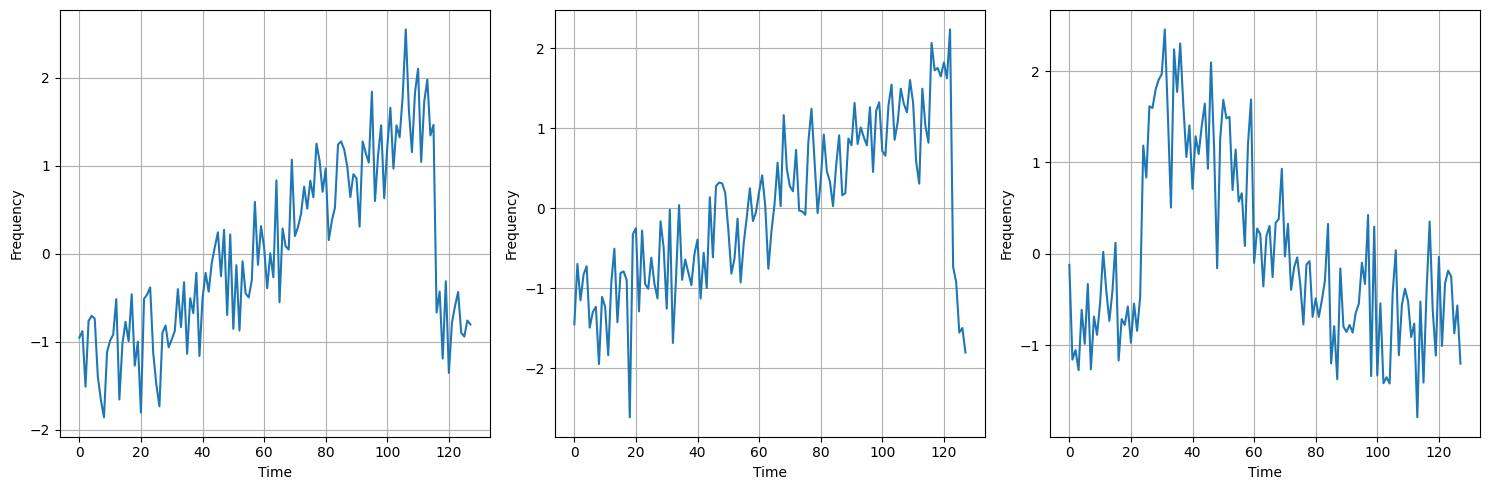

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(X_train[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)

plt.tight_layout()
plt.savefig("fig/Série a ser analisada")
plt.show()

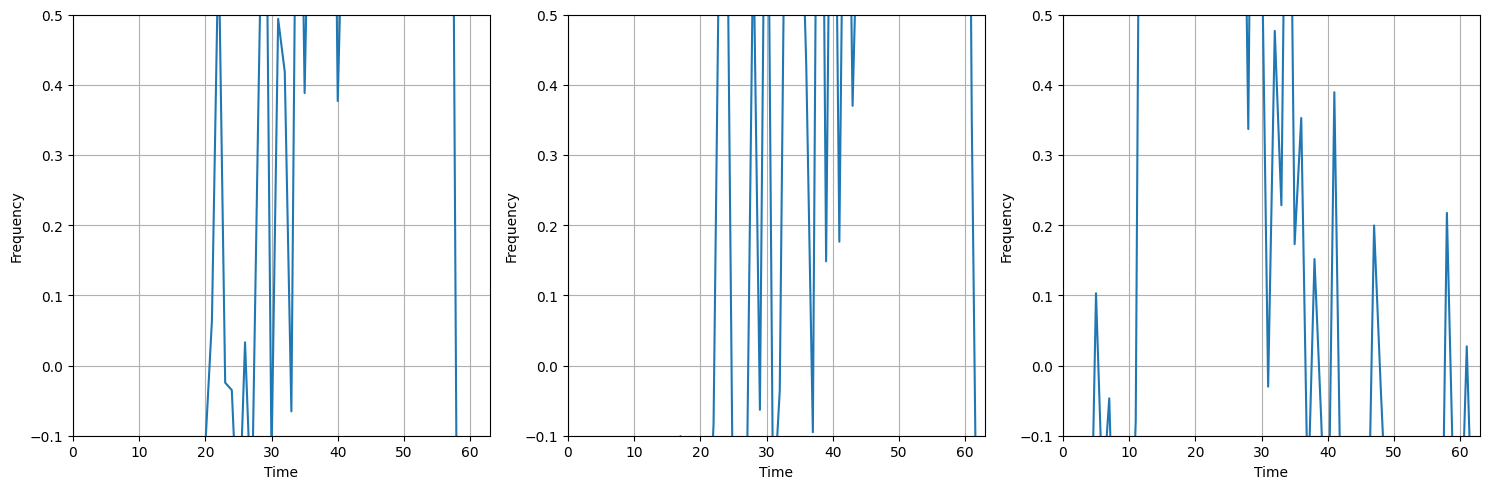

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

indices = [3, 4, 5]

for i, idx in enumerate(indices):
    axes[i].plot(encoded[idx])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")
    axes[i].grid(True)
    axes[i].set_xlim(0, X_train.shape[1] / modelo.pool_size - 1)
    axes[i].set_ylim(-0.1, 0.5)

plt.tight_layout()
plt.savefig("fig/Representação no espaço latente")
plt.show()



In [48]:
y_test_pred = modelo.predict(X_test)

y_test_aligned = np.array([mapping[c] for c in y_test_pred])
acc = (y_test_aligned == y_test).mean()
acc

np.float64(0.4)

In [49]:
y_test

array([1, 1, 1, 3, 2, 2, 1, 3, 2, 1, 2, 2, 1, 2, 2, 3, 2, 2, 1, 3, 2, 2,
       1, 1, 3, 3, 2, 3, 3, 1])

In [50]:
y_test_aligned

array([3, 3, 3, 2, 2, 2, 3, 3, 3, 3, 3, 2, 1, 3, 2, 3, 1, 3, 2, 3, 1, 3,
       3, 1, 3, 3, 1, 3, 2, 3])